<a href="https://colab.research.google.com/github/akshatsharma-x/ML/blob/main/ML_LAB_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ML LAB-11: NATURAL LANGUAGE PROCESSING - PREPROCESSING & VECTORIZATION

0. Initializing NLTK Resources...
✓ NLTK resources verified/downloaded

EXPERIMENT-1: TEXT PREPROCESSING PIPELINE
--------------------------------------------------------------------------------

1. Original Text:
   "Natural Language Processing (NLP) is amazing! It allows machines to understand human language."

2. Lowercased Text:
   "natural language processing (nlp) is amazing! it allows machines to understand human language."

3. Tokenization (17 tokens):
   ['natural', 'language', 'processing', '(', 'nlp', ')', 'is', 'amazing', '!', 'it', 'allows', 'machines', 'to', 'understand', 'human', 'language', '.']

4. Punctuation Removal (13 tokens):
   ['natural', 'language', 'processing', 'nlp', 'is', 'amazing', 'it', 'allows', 'machines', 'to', 'understand', 'human', 'language']

5. Stopword Removal (10 tokens):
   ['natural', 'language', 'processing', 'nlp', 'amazing', 'allows', 'machines', 'understand', 'human', 

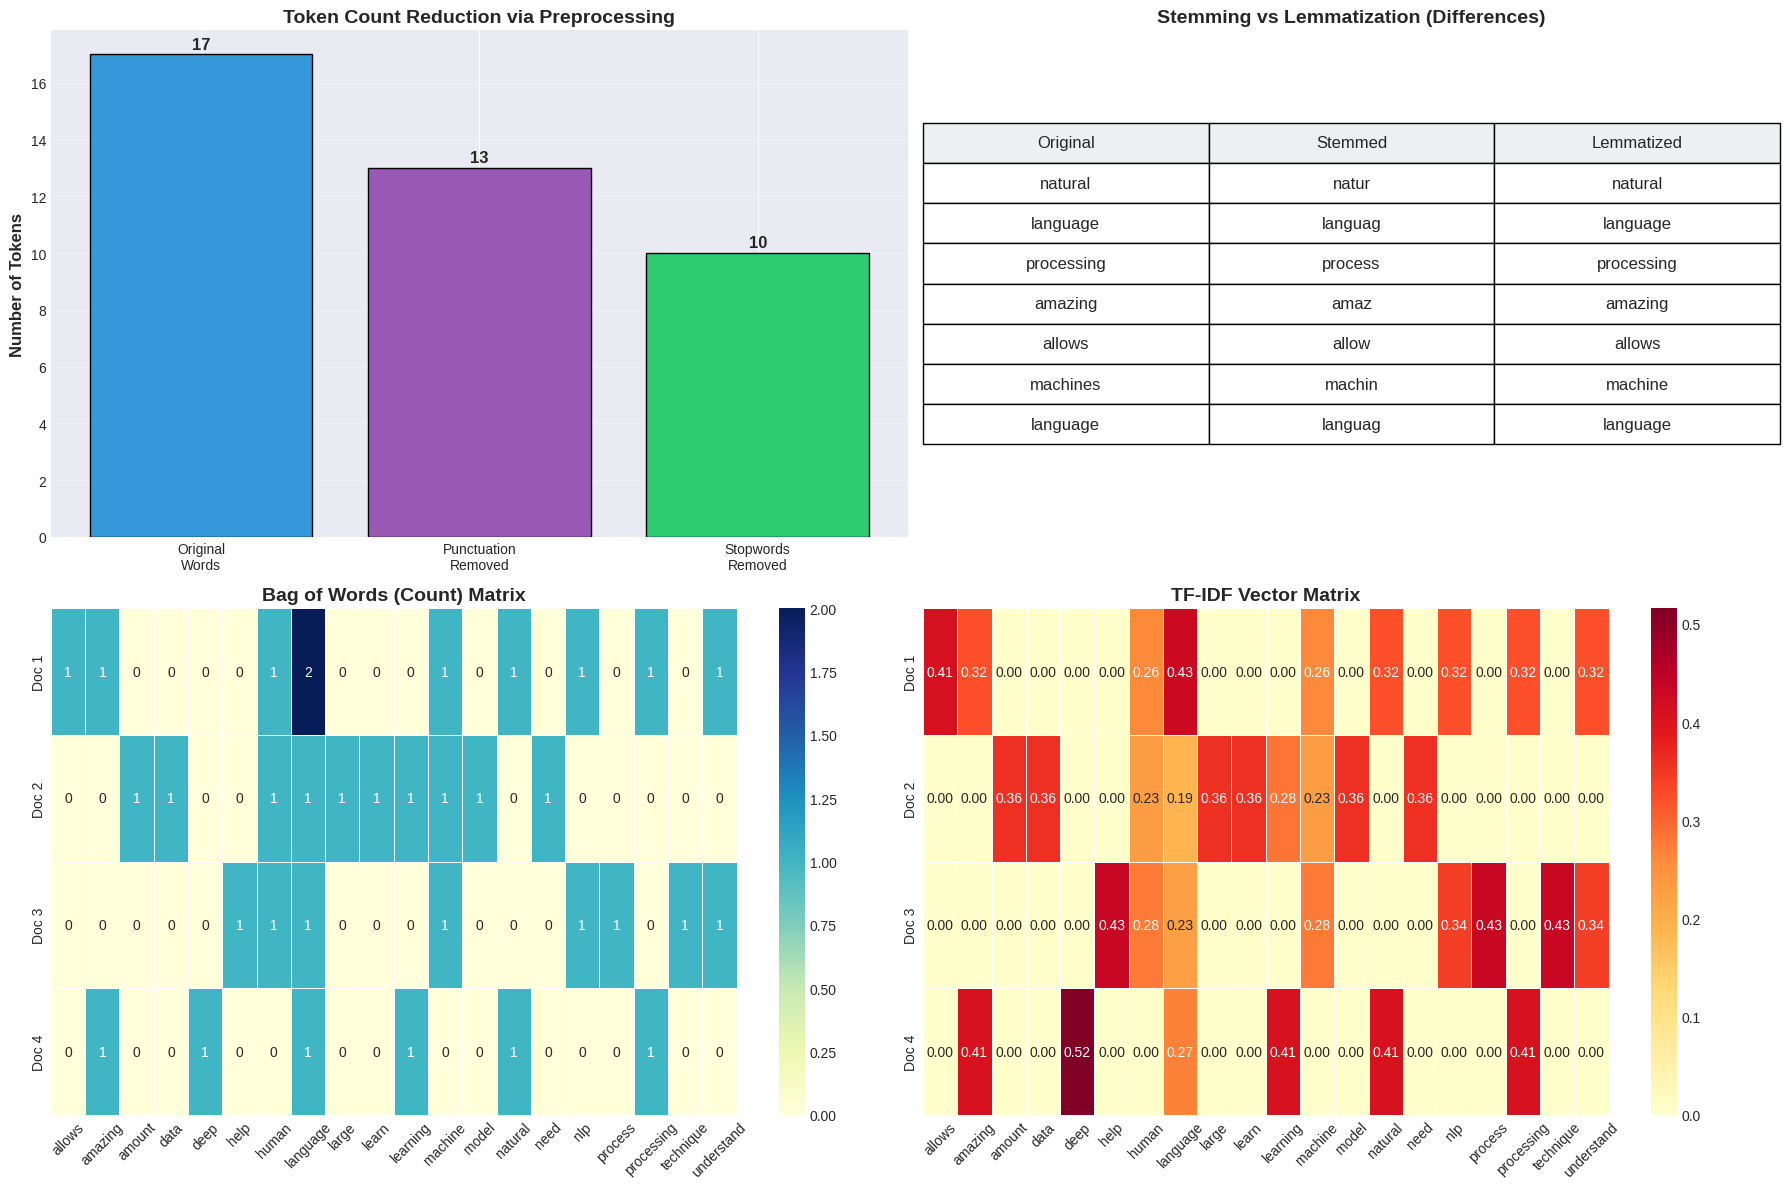


SUMMARY AND ANALYSIS

1. Why do we remove Stopwords and Punctuation?
  → Stopwords (is, at, which, on) and punctuation appear frequently but carry
  little semantic meaning. Removing them reduces the dimensionality of our
  dataset and helps the model focus on the actual subject matter.

2. Stemming vs. Lemmatization: Which is better?
  → Lemmatization is generally better for interpretation.
  - Stemming uses crude heuristic rules (e.g., chopping off 'ing' or 'es').
    It can produce non-words (e.g., 'machines' -> 'machin').
  - Lemmatization uses a vocabulary and morphological analysis to return
    valid base dictionary words (e.g., 'machines' -> 'machine').

3. Bag of Words vs. TF-IDF: What is the difference?
  → Bag of Words (BoW) simply counts the frequency of words in a document.
    It treats all words equally, so common words can dominate the matrix.
  → TF-IDF (Term Frequency-Inverse Document Frequency) balances the count.
    It increases the weight of words that occur freq

In [1]:
"""
ML LAB-11: NATURAL LANGUAGE PROCESSING
Text Preprocessing and Vectorization (BoW & TF-IDF)
"""

import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("ML LAB-11: NATURAL LANGUAGE PROCESSING - PREPROCESSING & VECTORIZATION")
print("=" * 80)
print()
print("0. Initializing NLTK Resources...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("✓ NLTK resources verified/downloaded")

# ============================================================================
# EXPERIMENT-1: TEXT PREPROCESSING PIPELINE
# ============================================================================
print("\nEXPERIMENT-1: TEXT PREPROCESSING PIPELINE")
print("-" * 80)

# 1. Define Sample Text
text = "Natural Language Processing (NLP) is amazing! It allows machines to understand human language."
print("\n1. Original Text:")
print(f"   \"{text}\"")

# 2. Lowercasing
text_lower = text.lower()
print("\n2. Lowercased Text:")
print(f"   \"{text_lower}\"")

# 3. Tokenization
tokens = word_tokenize(text_lower)
print(f"\n3. Tokenization ({len(tokens)} tokens):")
print(f"   {tokens}")

# 4. Remove punctuation
tokens_no_punct = [word for word in tokens if word not in string.punctuation]
print(f"\n4. Punctuation Removal ({len(tokens_no_punct)} tokens):")
print(f"   {tokens_no_punct}")

# 5. Stopword removal
stop_words = set(stopwords.words('english'))
tokens_no_stop = [word for word in tokens_no_punct if word not in stop_words]
print(f"\n5. Stopword Removal ({len(tokens_no_stop)} tokens):")
print(f"   {tokens_no_stop}")

# 6. Stemming vs Lemmatization (Comparison)
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(word) for word in tokens_no_stop]

lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens_no_stop]

print("\n6. Root Word Extraction Comparison:")
print(f"   Stemmed Tokens:    {stemmed_tokens}")
print(f"   Lemmatized Tokens: {lemmatized_tokens}")

processed_text = " ".join(lemmatized_tokens)
print("\n7. Final Processed String:")
print(f"   \"{processed_text}\"")

print("\n" + "=" * 80)

# ============================================================================
# EXPERIMENT-2: TEXT VECTORIZATION (BoW vs TF-IDF)
# ============================================================================
print("\nEXPERIMENT-2: TEXT VECTORIZATION COMPARISON")
print("-" * 80)

print("\n1. Defining Corpus for Vectorization...")
corpus = [
    text,
    "Machine learning models need large amounts of data to learn human language.",
    "NLP techniques help machines process and understand human language.",
    "Deep learning is amazing for processing natural language."
]

# Preprocess the entire corpus for accurate vectorization
def preprocess_document(doc):
    tokens = word_tokenize(doc.lower())
    clean_tokens = [lemmatizer.lemmatize(w) for w in tokens
                    if w not in string.punctuation and w not in stop_words]
    return " ".join(clean_tokens)

processed_corpus = [preprocess_document(doc) for doc in corpus]

for i, doc in enumerate(processed_corpus):
    print(f"   Doc {i+1}: {doc}")

# 2. Bag of Words (Count Vectorizer)
print("\n2. Applying Bag of Words (CountVectorizer)...")
count_vectorizer = CountVectorizer()
bow_matrix = count_vectorizer.fit_transform(processed_corpus)
bow_feature_names = count_vectorizer.get_feature_names_out()

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_feature_names,
                      index=[f"Doc {i+1}" for i in range(len(corpus))])
print("✓ Bag of Words matrix generated")

# 3. TF-IDF Vectorization
print("\n3. Applying TF-IDF Vectorization...")
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_corpus)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names,
                        index=[f"Doc {i+1}" for i in range(len(corpus))])
print("✓ TF-IDF matrix generated")

print("\n" + "=" * 80)

# ============================================================================
# VISUALIZATIONS
# ============================================================================
print("\nGenerating NLP Visualizations...")

fig = plt.figure(figsize=(18, 12))
fig.canvas.manager.set_window_title('NLP Preprocessing and Vectorization Visualizations')

# 1. Pipeline Token Reduction Breakdown
ax1 = plt.subplot(2, 2, 1)
stages = ['Original\nWords', 'Punctuation\nRemoved', 'Stopwords\nRemoved']
counts = [len(tokens), len(tokens_no_punct), len(tokens_no_stop)]
bars = ax1.bar(stages, counts, color=['#3498db', '#9b59b6', '#2ecc71'], edgecolor='black')
ax1.set_ylabel('Number of Tokens', fontsize=12, fontweight='bold')
ax1.set_title('Token Count Reduction via Preprocessing', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Stemming vs Lemmatization Differences
ax2 = plt.subplot(2, 2, 2)
ax2.axis('off')
diff_table = []
for orig, stem, lem in zip(tokens_no_stop, stemmed_tokens, lemmatized_tokens):
    if stem != lem or orig != lem:
        diff_table.append([orig, stem, lem])

table = ax2.table(cellText=diff_table, colLabels=['Original', 'Stemmed', 'Lemmatized'],
                  loc='center', cellLoc='center', colColours=['#ecf0f1']*3)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
ax2.set_title('Stemming vs Lemmatization (Differences)', fontsize=14, fontweight='bold')

# 3. Bag of Words Heatmap
ax3 = plt.subplot(2, 2, 3)
sns.heatmap(bow_df, annot=True, cmap='YlGnBu', cbar=True, ax=ax3, linewidths=0.5)
ax3.set_title('Bag of Words (Count) Matrix', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# 4. TF-IDF Heatmap
ax4 = plt.subplot(2, 2, 4)
sns.heatmap(tfidf_df, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True, ax=ax4, linewidths=0.5)
ax4.set_title('TF-IDF Vector Matrix', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
print("Displaying Visualizations... (Close the window to continue)")
plt.show()

# ============================================================================
# SUMMARY AND ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY AND ANALYSIS")
print("=" * 80)

print("\n1. Why do we remove Stopwords and Punctuation?")
print("  → Stopwords (is, at, which, on) and punctuation appear frequently but carry")
print("  little semantic meaning. Removing them reduces the dimensionality of our")
print("  dataset and helps the model focus on the actual subject matter.")

print("\n2. Stemming vs. Lemmatization: Which is better?")
print("  → Lemmatization is generally better for interpretation.")
print("  - Stemming uses crude heuristic rules (e.g., chopping off 'ing' or 'es').")
print("    It can produce non-words (e.g., 'machines' -> 'machin').")
print("  - Lemmatization uses a vocabulary and morphological analysis to return")
print("    valid base dictionary words (e.g., 'machines' -> 'machine').")

print("\n3. Bag of Words vs. TF-IDF: What is the difference?")
print("  → Bag of Words (BoW) simply counts the frequency of words in a document.")
print("    It treats all words equally, so common words can dominate the matrix.")
print("  → TF-IDF (Term Frequency-Inverse Document Frequency) balances the count.")
print("    It increases the weight of words that occur frequently in ONE document,")
print("    but penalizes words that occur frequently across ALL documents.")
print("    Notice in the TF-IDF heatmap how unique words get higher scores than")
print("    words shared across multiple sentences like 'language'.")

print("\n" + "=" * 80)
print("LAB 11 COMPLETED SUCCESSFULLY!")
print("=" * 80)